#Data Quality and Validation in ETL

Question 1 : Define Data Quality in the context of ETL pipelines. Why is it more than just data cleaning?

 - Data Quality in an ETL pipeline refers to the overall condition of data, ensuring that it is accurate, complete, consistent, valid, unique, and timely before it is loaded into the target system. High-quality data helps organizations make reliable decisions and improves the performance of reporting, analytics, and business intelligence systems.

   Data quality is more than just data cleaning because it covers the entire lifecycle of data management. While data cleaning focuses on correcting errors such as missing values, duplicate records, and incorrect formats, data quality also includes validating business rules, maintaining consistency across multiple data sources, ensuring data integrity, monitoring quality continuously, and preventing future data issues.

Question 2 : Explain why poor data quality leads to misleading dashboards and incorrect decisions.

 - Poor data quality in an ETL pipeline can result in misleading dashboards and incorrect business decisions because dashboards and reports rely entirely on the accuracy and reliability of the underlying data. If the source data contains errors, duplicates, missing values, or inconsistent formats, these problems are carried into the reports and analytics.

   Poor data quality can also reduce customer satisfaction, increase operational costs, and decrease trust in business intelligence systems. Therefore, maintaining high data quality through validation, cleansing, and monitoring is essential for producing reliable dashboards and supporting informed decision-making.

Question 3 : What is duplicate data? Explain three causes in ETL pipelines.

 - Duplicate data refers to the presence of two or more records that represent the same real-world entity in a database or data warehouse. Duplicate records increase storage costs, reduce data quality, and lead to inaccurate reports and analysis in an ETL pipeline.

   **Three Causes of Duplicate Data in ETL Pipelines:-**

   - Multiple Data Sources:- The same data may be collected from different systems.

     Without proper matching and merging, the ETL process may load the same record multiple times.

   - Repeated ETL Loads:-  If the ETL process is run multiple times without checking previously loaded data, the same records may be inserted again.
   
     This often happens when incremental loading is not implemented correctly.

   - Lack of Unique Identifiers:- When records do not have a unique key, the ETL process cannot identify duplicate records.
   
     As a result, multiple copies of the same data may be stored.

Question 4 : Differentiate between exact, partial, and fuzzy duplicates.

 - Duplicate records can be classified into exact, partial, and fuzzy duplicates based on how closely the records match each other. Identifying these duplicates is important in ETL pipelines to improve data quality and ensure accurate reporting.
  
 ** Difference Between Exact, Partial, and Fuzzy Duplicates**

 - Exact Duplicate:- Two or more records are completely identical in all important fields.

   Exact Duplicate Records are 100% identical.

  - Partial Duplicate:- Records share some common information but differ in one or more fields.

     Partial Duplicate Records are partially similar but differ in some fields.

  - Fuzzy Duplicate:- Records refer to the same entity but contain spelling differences, abbreviations, or formatting variations.

     Fuzzy Duplicate Records represent the same entity with minor spelling or formatting differences.

Question 5 : Why should data validation be performed during transformation rather than after loading?

 - Data validation should be performed during the transformation stage rather than after loading because it ensures that only accurate, complete, and consistent data is loaded into the target system. Detecting errors before loading prevents bad-quality data from affecting reports, analytics, and business decisions.

 - Reasons:-

   - Prevents Invalid Data from Entering the Database

     Incorrect or missing values are identified and corrected before loading.
     
     This keeps the target database clean and reliable.
     
    - Reduces Rework

      Fixing errors during transformation is easier than correcting records after they have already been loaded.

    - Maintains Data Integrity

      Validation checks such as data type, range, format, and business rules ensure the data remains accurate and consistent.

    - Improves ETL Performance
     
     Invalid records can be filtered or redirected before loading, reducing the need for costly updates or reloads later.

    - Produces Reliable Reports

     Since only validated data is loaded, dashboards and analytical reports provide accurate insights for decision-making.

Question 6 : Explain how business rules help in validating data accuracy. Give an example.

 - Business rules are predefined conditions or standards that data must satisfy before it is loaded into the target system. During the transformation stage of ETL, these rules are used to validate data accuracy, consistency, and compliance with organizational policies. Records that do not meet the business rules are rejected, corrected, or sent for review.

 - How Business Rules Help in Data Validation:-

   Ensure Accuracy-

   Verify that data values are correct and meaningful.
   
   Maintain Consistency-

   Ensure all records follow the same business standards and formats.
   
   Prevent Invalid Data-


   Detect missing, incorrect, or out-of-range values before loading.
  
   Support Business Policies-

   Ensure data complies with organizational requirements and regulations.

   Improve Data Quality-

   Only valid and reliable data is loaded into the target database.

   **Example:-**

   A company has a business rule that an employee's age must be between 18 and 60 years:-

| Employee ID | Age | Validation Result              |
|--------------|-----|--------------------------------|
| E101         | 25  |  Valid                       |
| E102         | 17  |  Invalid (Below minimum age) |
| E103         | 45  |  Valid                       |
| E104         | 65  |  Invalid (Above maximum age) |



Use the following Sales_Transactions dataset for all questions:

| Txn_ID | Customer_ID | Customer_Name | Product_ID | Quantity | Txn_Amount | Txn_Date   | City      |
|--------|-------------|---------------|------------|----------|------------|------------|-----------|
| 201    | C101        | Rahul Mehta   | P11        | 2        | 4000       | 2025-12-01 | Mumbai    |
| 202    | C102        | Anjali Rao    | P12        | 1        | 1500       | 2025-12-01 | Bengaluru |
| 203    | C101        | Rahul Mehta   | P11        | 2        | 4000       | 2025-12-01 | Mumbai    |
| 204    | C103        | Suresh Iyer   | P13        | 3        | 6000       | 2025-12-02 | Chennai   |
| 205    | C104        | Neha Singh    | P14        | NULL     | 2500       | 2025-12-02 | Delhi     |
| 206    | C105        | N/A           | P15        | 1        | NULL       | 2025-12-03 | Pune      |
| 207    | C106        | Amit Verma    | P16        | 1        | 1800       | NULL       | Pune      |
| 208    | C101        | Rahul Mehta   | P11        | 2        | 4000       | 2025-12-01 | Mumbai    |

Question 7 : Write an SQL query on Sales_Transactions to list all duplicate keys and their counts using the
business key (Customer_ID + Product_ID + Txn_Date + Txn_Amount )

$$
SQL QUERY
$$


In [ ]:
SELECT
    Customer_ID,
    Product_ID,
    Txn_Date,
    Txn_Amount,
    COUNT(*) AS Duplicate_Count
FROM Sales_Transactions
GROUP BY
    Customer_ID,
    Product_ID,
    Txn_Date,
    Txn_Amount
HAVING COUNT(*) > 1;

OUTPUT:-

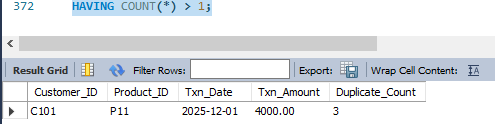

Question 8 : Enforcing Referential Integrity

Assume the following Customers_Master table:

| CustomerID | CustomerName | City      |
|------------|--------------|-----------|
| C101       | Rahul Mehta  | Mumbai    |
| C102       | Anjali Rao   | Bengaluru |
| C103       | Suresh Iyer  | Chennai   |
| C104       | Neha Singh   | Delhi     |

Identify Sales_Transactions.Customer_ID values that violate referential integrity when joined with
Customers_Master and write a query to detect such violations

$$
SQL QUERY
$$

In [ ]:
SELECT
    st.Txn_ID,
    st.Customer_ID,
    st.Customer_Name,
    st.Product_ID,
    st.City
FROM Sales_Transactions st
LEFT JOIN Customers_Master cm
ON st.Customer_ID = cm.CustomerID
WHERE cm.CustomerID IS NULL;

OUTPUT:-

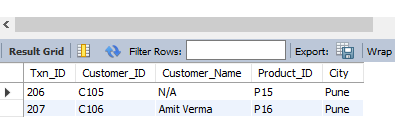

$$
***
$$